In [67]:
!pip install seaborn matplotlib

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [70]:
clean_data.shape

(3724889, 21)

In [71]:
df = clean_data.copy()

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 21 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   vendor_id                     int8          
 1   pickup_datetime               datetime64[us]
 2   dropoff_datetime              datetime64[us]
 3   passenger_count               float64       
 4   trip_distance                 float64       
 5   fare_type_id                  float64       
 6   store_and_fwd_flag            str           
 7   pickup_location_id            int32         
 8   dropoff_location_id           int32         
 9   payment_type                  int64         
 10  fare_amount                   float64       
 11  extra_amount                  float64       
 12  mta_tax_amount                float64       
 13  tip_amount                    float64       
 14  tolls_amount                  float64       
 15  improvement_surcharge_amount  float64      

In [73]:
df['passenger_count'].isna().sum() / df.shape[0]

np.float64(0.2921048117138524)

In [74]:
df['passenger_count'].describe()

count    2.636831e+06
mean     1.256271e+00
std      6.702431e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

# check the distribution

In [75]:
df['passenger_count'].value_counts(dropna=False)

passenger_count
1.0    2150994
NaN    1088058
2.0     334370
3.0      72864
4.0      49738
0.0      14787
5.0       9184
6.0       4887
8.0          4
7.0          2
9.0          1
Name: count, dtype: int64

<Axes: xlabel='passenger_count'>

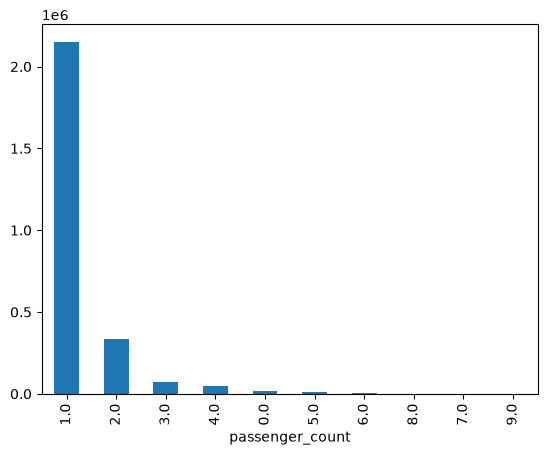

In [76]:
df['passenger_count'].value_counts().plot(kind='bar')

# check passenger null values

In [77]:
tempdf = df[df['passenger_count'].isna()].copy()

In [78]:
cols = [
    "passenger_count",
    "fare_type_id",
    "store_and_fwd_flag",
    "congestion_surcharge_amount",
    "airport_fee_amount"
]

tempdf[cols].isna().sum()


passenger_count                1088058
fare_type_id                   1088058
store_and_fwd_flag             1088058
congestion_surcharge_amount    1088058
airport_fee_amount             1088058
dtype: int64

In [79]:
df.dropna(subset=['passenger_count'], inplace=True)

In [80]:
df.shape

(2636831, 21)

In [81]:
tempdf = pd.read_parquet("../raw_data/yellow_tripdata_2026-01.parquet")

In [82]:
tempdf = tempdf[tempdf['passenger_count'].isna()]

<Axes: xlabel='tpep_pickup_datetime'>

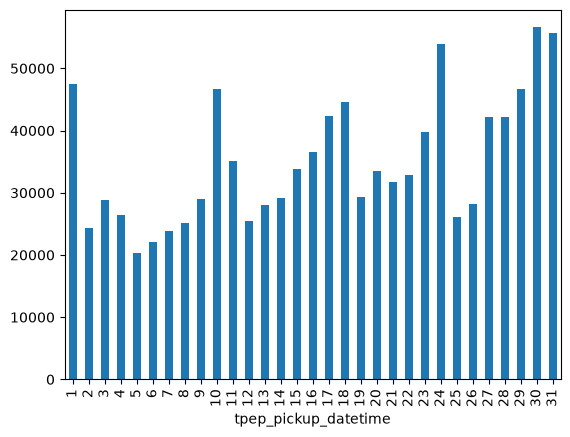

In [83]:
tempdf['tpep_pickup_datetime'].dt.day.value_counts(dropna=False).sort_index().plot(kind="bar")

<Axes: xlabel='tpep_pickup_datetime'>

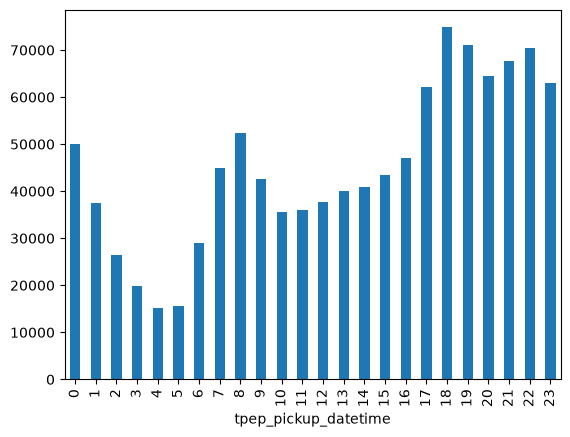

In [84]:
tempdf['tpep_pickup_datetime'].dt.hour.value_counts(dropna=False).sort_index().plot(kind='bar')

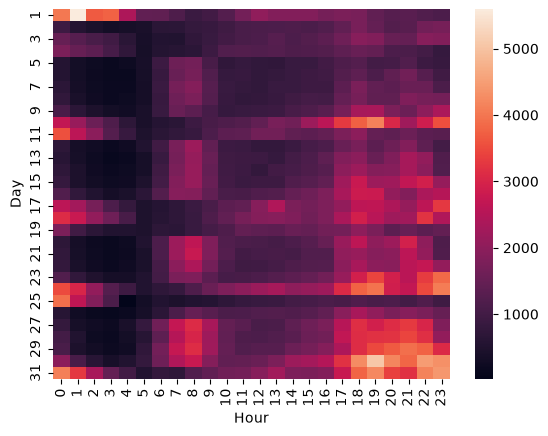

In [85]:
sns.heatmap(pd.crosstab(
    tempdf['tpep_pickup_datetime'].dt.day,
    tempdf['tpep_pickup_datetime'].dt.hour,
))

plt.xlabel('Hour')
plt.ylabel('Day')
plt.show()

# check trips of passenger count > 6

In [86]:
df = df[df['passenger_count'] <= 6]

In [87]:
df.shape

(2636824, 21)

# check for 0 passengers 

In [88]:
df[df['passenger_count'] == 0].sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,extra_amount,mta_tax_amount,tip_amount,tolls_amount,improvement_surcharge_amount,total_amount,congestion_surcharge_amount,airport_fee_amount,cbd_congestion_fee_amount,vendor_name
1439698,1,2026-01-17 15:49:54,2026-01-17 15:55:45,0.0,0.6,1.0,N,164,68,1,...,3.25,0.5,2.35,0.0,1.0,14.3,2.5,0.0,0.75,"Creative Mobile Technologies, LLC"


In [89]:
(df['passenger_count'].value_counts()[0] / df.shape[0]) * 100

np.float64(0.5607882816600577)

In [90]:
df = df[df['passenger_count'] > 0]

In [91]:
df['passenger_count'].value_counts(dropna=False)

passenger_count
1.0    2150994
2.0     334370
3.0      72864
4.0      49738
5.0       9184
6.0       4887
Name: count, dtype: int64

# change data type

In [92]:
df['passenger_count'] = df['passenger_count'].astype('int8')

In [93]:
df.info()

<class 'pandas.DataFrame'>
Index: 2622037 entries, 0 to 2636830
Data columns (total 21 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   vendor_id                     int8          
 1   pickup_datetime               datetime64[us]
 2   dropoff_datetime              datetime64[us]
 3   passenger_count               int8          
 4   trip_distance                 float64       
 5   fare_type_id                  float64       
 6   store_and_fwd_flag            str           
 7   pickup_location_id            int32         
 8   dropoff_location_id           int32         
 9   payment_type                  int64         
 10  fare_amount                   float64       
 11  extra_amount                  float64       
 12  mta_tax_amount                float64       
 13  tip_amount                    float64       
 14  tolls_amount                  float64       
 15  improvement_surcharge_amount  float64       
 16

In [94]:
df.shape

(2622037, 21)

# vendor 6 only has dirty data for passenger count

In [95]:
df['vendor_id'].value_counts()

vendor_id
2    2019730
1     557602
7      44705
Name: count, dtype: int64

# save to clean data

In [96]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

# function to clean passenger count

In [97]:
def clean_passenger_count(df):
    df.dropna(subset=['passenger_count'], inplace=True)
    df = df[df['passenger_count'] <= 6]
    df = df[df['passenger_count'] > 0]
    df['passenger_count'] = df['passenger_count'].astype('int8')